In [87]:
import pandas as pd
import numpy as np
import subprocess
import os
from datetime import datetime, timedelta, time, date
import datetime
from datetime import datetime
import locale
import seaborn as sns
import matplotlib.pyplot as plt
import re

In [88]:
mes = 'Mayo'
año = '2026'

In [89]:
#Importar archivos de acciones reg Zonal

carpeta_origen = 'Z:/01 base_datos/09 acciones_regulacion_FMS'

dataframes = [] # Lista para almacenar cada archivo

fecha_inicio = '01/05/2026'  
fecha_fin = '31/05/2026'  

for archivo in os.listdir(carpeta_origen):
    if archivo.endswith('.csv'):  # Filtra solo los archivos con extensión .csv
        ruta_archivo = os.path.join(carpeta_origen, archivo)
        df = pd.read_csv(ruta_archivo, encoding='latin')
        
        # Obtener la fecha del nombre del archivo
        fecha_archivo = pd.to_datetime(archivo.split('_')[0], format='%Y%m%d', errors='coerce')

        # Filtrar por fechas
        if fecha_archivo >= pd.to_datetime(fecha_inicio, format='%d/%m/%Y') and fecha_archivo <= pd.to_datetime(fecha_fin, format='%d/%m/%Y'):
            dataframes.append(df)  # Agregar el DataFrame a la lista

# Combinar todos los DataFrames en uno solo
if dataframes:
    resultado = pd.concat(dataframes)

    # Imprimir el resultado
    resultado
else:
    print("No se encontraron archivos que cumplan con el filtro de fechas.")

resultado.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por
0,1/05/2026,1:19:38,10273,142,2.0,NaN,NaN,20,Cambiar Conductor,RTELLEZ_105,ROSA MARIELA TELLEZ NAVARRO,com.lgcns.fms.oprt.schedule.driver.model.Chang...,0,Motivo no definido.,NaN
1,1/05/2026,1:20:17,10273,142,6.0,NaN,NaN,20,Cambiar Conductor,RTELLEZ_105,ROSA MARIELA TELLEZ NAVARRO,com.lgcns.fms.oprt.schedule.driver.model.Chang...,0,Motivo no definido.,NaN
2,1/05/2026,1:21:08,10273,142,1.0,NaN,NaN,20,Cambiar Conductor,RTELLEZ_105,ROSA MARIELA TELLEZ NAVARRO,com.lgcns.fms.oprt.schedule.driver.model.Chang...,0,Motivo no definido.,NaN
3,1/05/2026,1:21:55,10325,576,14.0,NaN,NaN,20,Cambiar Conductor,RTELLEZ_105,ROSA MARIELA TELLEZ NAVARRO,com.lgcns.fms.oprt.schedule.driver.model.Chang...,0,Motivo no definido.,NaN
4,1/05/2026,1:23:10,10325,576,16.0,NaN,NaN,20,Cambiar Conductor,RTELLEZ_105,ROSA MARIELA TELLEZ NAVARRO,com.lgcns.fms.oprt.schedule.driver.model.Chang...,0,Motivo no definido.,NaN


In [90]:
# Convertir columna a entero
resultado['Id Acción'] = (
    pd.to_numeric(
        resultado['Id Acción'],
        errors='coerce'
    )
    .fillna(0)
    .astype(int)
)

resultado.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por
0,1/05/2026,1:19:38,10273,142,2.0,NaN,NaN,20,Cambiar Conductor,RTELLEZ_105,ROSA MARIELA TELLEZ NAVARRO,com.lgcns.fms.oprt.schedule.driver.model.Chang...,0,Motivo no definido.,NaN
1,1/05/2026,1:20:17,10273,142,6.0,NaN,NaN,20,Cambiar Conductor,RTELLEZ_105,ROSA MARIELA TELLEZ NAVARRO,com.lgcns.fms.oprt.schedule.driver.model.Chang...,0,Motivo no definido.,NaN
2,1/05/2026,1:21:08,10273,142,1.0,NaN,NaN,20,Cambiar Conductor,RTELLEZ_105,ROSA MARIELA TELLEZ NAVARRO,com.lgcns.fms.oprt.schedule.driver.model.Chang...,0,Motivo no definido.,NaN
3,1/05/2026,1:21:55,10325,576,14.0,NaN,NaN,20,Cambiar Conductor,RTELLEZ_105,ROSA MARIELA TELLEZ NAVARRO,com.lgcns.fms.oprt.schedule.driver.model.Chang...,0,Motivo no definido.,NaN
4,1/05/2026,1:23:10,10325,576,16.0,NaN,NaN,20,Cambiar Conductor,RTELLEZ_105,ROSA MARIELA TELLEZ NAVARRO,com.lgcns.fms.oprt.schedule.driver.model.Chang...,0,Motivo no definido.,NaN


In [91]:
# resultado = resultado.rename(columns={

#     'accidentes_nivel_1': 'AS',
#     'accidentes_nivel_2': 'AL',

# })

# resultado.head()

In [92]:
# Lista de valores de Accion que deseas incluir en el filtro
valores_interes = [2]

# Filtrar el DataFrame por los valores de Accion de interés
resultado = resultado[resultado['Id Motivo'].isin(valores_interes)]

resultado.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por
326,1/05/2026,11:22:28,10304,806,3.0,Z50-4298,504298.0,5,Eliminar Vehiculo,CPRADA_105,CATHERINE YISELL PRADA MORENO,"<= Elimination Vehicle =>\nIdLinea=10304,\nSer...",2,Bus varado en la via,NaN
476,1/05/2026,13:46:56,10184,740,19.0,Z50-4378,504378.0,5,Eliminar Vehiculo,EARIOS_105,Edgar Alejandro Rios Cardozo,"<= Elimination Vehicle =>\nIdLinea=10184,\nSer...",2,Bus varado en la via,NaN
544,1/05/2026,15:02:15,10350,SE14,11.0,Z50-7036,507036.0,5,Eliminar Vehiculo,MMARTIN_105,MARTHA IBETH MARTIN MARTIN,"<= Elimination Vehicle =>\nIdLinea=10350,\nSer...",2,Bus varado en la via,NaN
648,1/05/2026,16:58:09,10350,SE14,10.0,Z80-7017,807017.0,5,Eliminar Vehiculo,JROA_108,Jessica Andrea Roa Bejarano,"<= Elimination Vehicle =>\nIdLinea=10350,\nSer...",2,Bus varado en la via,NaN
659,1/05/2026,17:20:16,10342,KB309,4.0,Z50-2026,502026.0,5,Eliminar Vehiculo,JSANCHEZ_105,JULIAN SANCHEZ ANDRES RESTREPO,"<= Elimination Vehicle =>\nIdLinea=10342,\nSer...",2,Bus varado en la via,NaN


In [93]:
resultado = resultado[resultado['Id Usuario'].str.endswith('_105', na=False)]

resultado.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por
326,1/05/2026,11:22:28,10304,806,3.0,Z50-4298,504298.0,5,Eliminar Vehiculo,CPRADA_105,CATHERINE YISELL PRADA MORENO,"<= Elimination Vehicle =>\nIdLinea=10304,\nSer...",2,Bus varado en la via,NaN
476,1/05/2026,13:46:56,10184,740,19.0,Z50-4378,504378.0,5,Eliminar Vehiculo,EARIOS_105,Edgar Alejandro Rios Cardozo,"<= Elimination Vehicle =>\nIdLinea=10184,\nSer...",2,Bus varado en la via,NaN
544,1/05/2026,15:02:15,10350,SE14,11.0,Z50-7036,507036.0,5,Eliminar Vehiculo,MMARTIN_105,MARTHA IBETH MARTIN MARTIN,"<= Elimination Vehicle =>\nIdLinea=10350,\nSer...",2,Bus varado en la via,NaN
659,1/05/2026,17:20:16,10342,KB309,4.0,Z50-2026,502026.0,5,Eliminar Vehiculo,JSANCHEZ_105,JULIAN SANCHEZ ANDRES RESTREPO,"<= Elimination Vehicle =>\nIdLinea=10342,\nSer...",2,Bus varado en la via,NaN
730,1/05/2026,19:33:18,10342,KB309,9.0,Z50-2022,502022.0,5,Eliminar Vehiculo,JSANCHEZ_105,JULIAN SANCHEZ ANDRES RESTREPO,"<= Elimination Vehicle =>\nIdLinea=10342,\nSer...",2,Bus varado en la via,DCASTELLANOS_TM


In [94]:
# Filtrar el DataFrame resultado
resultado = resultado.loc[resultado['Id Acción'] != 5]

resultado.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por


C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_21436\3363173229.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


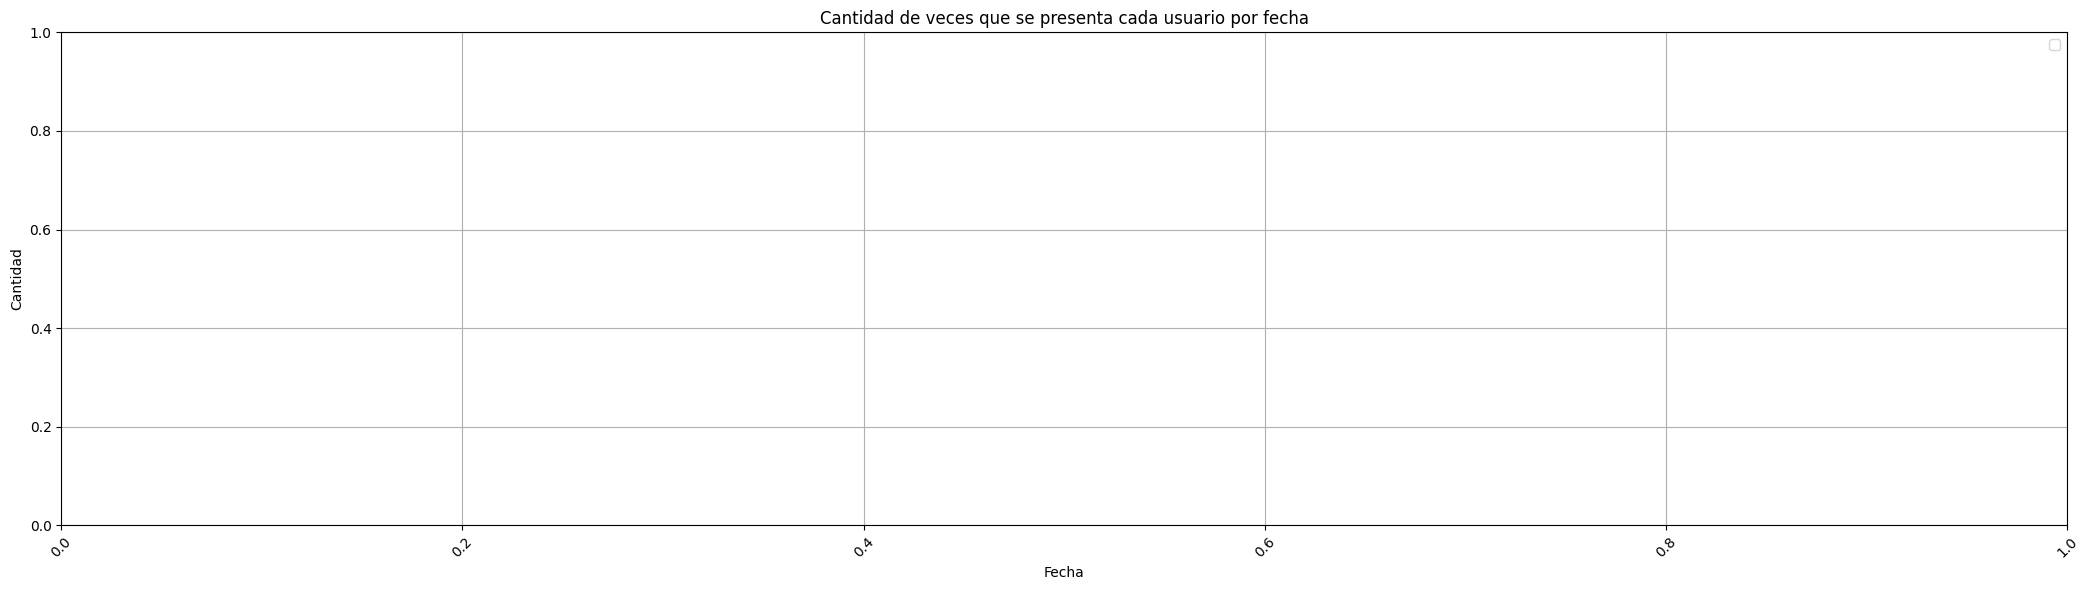

In [95]:
# Agrupar los datos por NombreUsuario y Fecha y contar las ocurrencias
conteo_por_fecha = resultado.groupby(['Nombre de Usuario', 'Fecha']).size().reset_index(name='Conteo')

# Crear la gráfica de barras
plt.figure(figsize=(21, 6))
for nombre_usuario in conteo_por_fecha['Nombre de Usuario'].unique():
    datos_usuario = conteo_por_fecha[conteo_por_fecha['Nombre de Usuario'] == nombre_usuario]
    plt.bar(datos_usuario['Fecha'], datos_usuario['Conteo'], label=nombre_usuario)

# Personalizar la gráfica
plt.xlabel('Fecha')
plt.ylabel('Cantidad')
plt.title('Cantidad de veces que se presenta cada usuario por fecha')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

# Mostrar la gráfica
plt.tight_layout()
plt.show()

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_21436\2123130661.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Fecha')


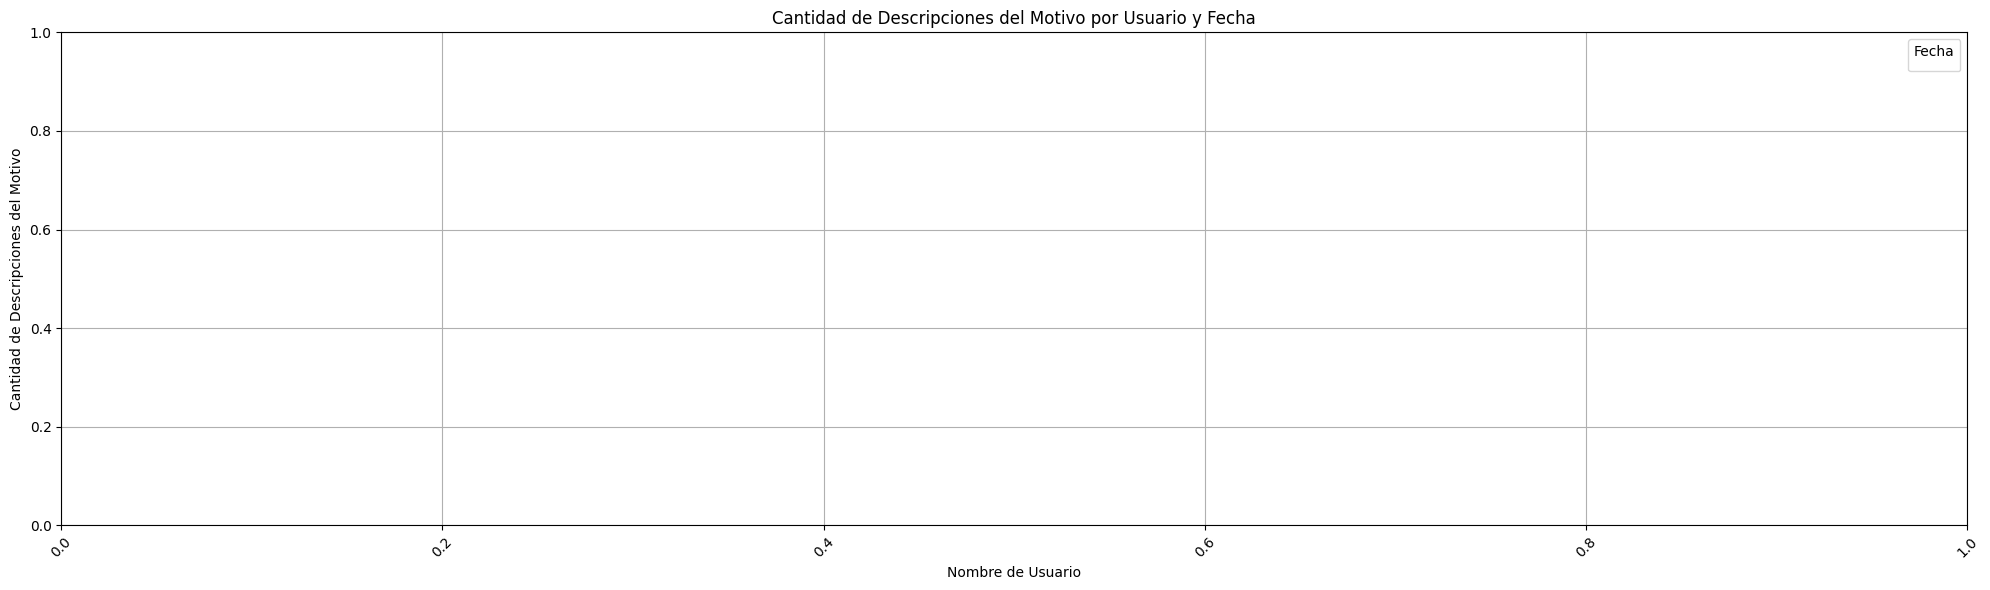

In [96]:
# Agrupar los datos por NombreUsuario y Fecha y contar las descripciones del motivo
conteo_por_usuario_fecha = resultado.groupby(['Nombre de Usuario', 'Fecha'])['Motivo'].count().reset_index(name='Cantidad')

# Crear la gráfica de barras
plt.figure(figsize=(20, 6))
for fecha in conteo_por_usuario_fecha['Fecha'].unique():
    datos_fecha = conteo_por_usuario_fecha[conteo_por_usuario_fecha['Fecha'] == fecha]
    plt.bar(datos_fecha['Nombre de Usuario'], datos_fecha['Cantidad'], label=fecha)

# Agregar etiquetas a las barras
for index, row in conteo_por_usuario_fecha.iterrows():
    plt.text(row['Nombre de Usuario'], row['Cantidad'], str(row['Cantidad']), ha='center', va='bottom')

# Personalizar la gráfica
plt.xlabel('Nombre de Usuario')
plt.ylabel('Cantidad de Descripciones del Motivo')
plt.title('Cantidad de Descripciones del Motivo por Usuario y Fecha')
plt.xticks(rotation=45)
plt.legend(title='Fecha')
plt.grid(True)

# Mostrar la gráfica
plt.tight_layout()
plt.show()

In [97]:
#Exportar data
resultado.to_csv(f'C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2025/Motivos_infracciones/{mes}_{año}.csv')